In [32]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split,GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split,StratifiedKFold, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier,AdaBoostClassifier,RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report,confusion_matrix
import pickle


In [33]:
df=pd.read_csv('brain_stroke.csv')
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


## **Data Expolration**

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4981 non-null   object 
 1   age                4981 non-null   float64
 2   hypertension       4981 non-null   int64  
 3   heart_disease      4981 non-null   int64  
 4   ever_married       4981 non-null   object 
 5   work_type          4981 non-null   object 
 6   Residence_type     4981 non-null   object 
 7   avg_glucose_level  4981 non-null   float64
 8   bmi                4981 non-null   float64
 9   smoking_status     4981 non-null   object 
 10  stroke             4981 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 428.2+ KB


In [35]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000
mean,43.419859,0.096165,0.055210,105.943562,28.498173,0.049789
std,22.662755,0.294848,0.228412,45.075373,6.790464,0.217531
min,0.080000,0.000000,0.000000,55.120000,14.000000,0.000000
25%,25.000000,0.000000,0.000000,77.230000,23.700000,0.000000
50%,45.000000,0.000000,0.000000,91.850000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,113.860000,32.600000,0.000000
max,82.000000,1.000000,1.000000,271.740000,48.900000,1.000000


In [36]:
df.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [37]:
df.duplicated().sum()

0

## **Data Visualization** 

In [38]:
numerical_data=df[['age','avg_glucose_level','bmi']]
numerical_data

,age,avg_glucose_level,bmi
0,67.0,228.69,36.6
1,80.0,105.92,32.5
2,49.0,171.23,34.4
3,79.0,174.12,24.0
4,81.0,186.21,29.0
...,...,...,...
4976,41.0,70.15,29.8
4977,40.0,191.15,31.1
4978,45.0,95.02,31.8
4979,40.0,83.94,30.0


In [39]:
categorical_data=df.select_dtypes(include=['object','int64'])
categorical_data

,gender,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,stroke
0,Male,0,1,Yes,Private,Urban,formerly smoked,1
1,Male,0,1,Yes,Private,Rural,never smoked,1
2,Female,0,0,Yes,Private,Urban,smokes,1
3,Female,1,0,Yes,Self-employed,Rural,never smoked,1
4,Male,0,0,Yes,Private,Urban,formerly smoked,1
...,...,...,...,...,...,...,...,...
4976,Male,0,0,No,Private,Rural,formerly smoked,0
4977,Male,0,0,Yes,Private,Urban,smokes,0
4978,Female,1,0,Yes,Govt_job,Rural,smokes,0
4979,Male,0,0,Yes,Private,Rural,smokes,0


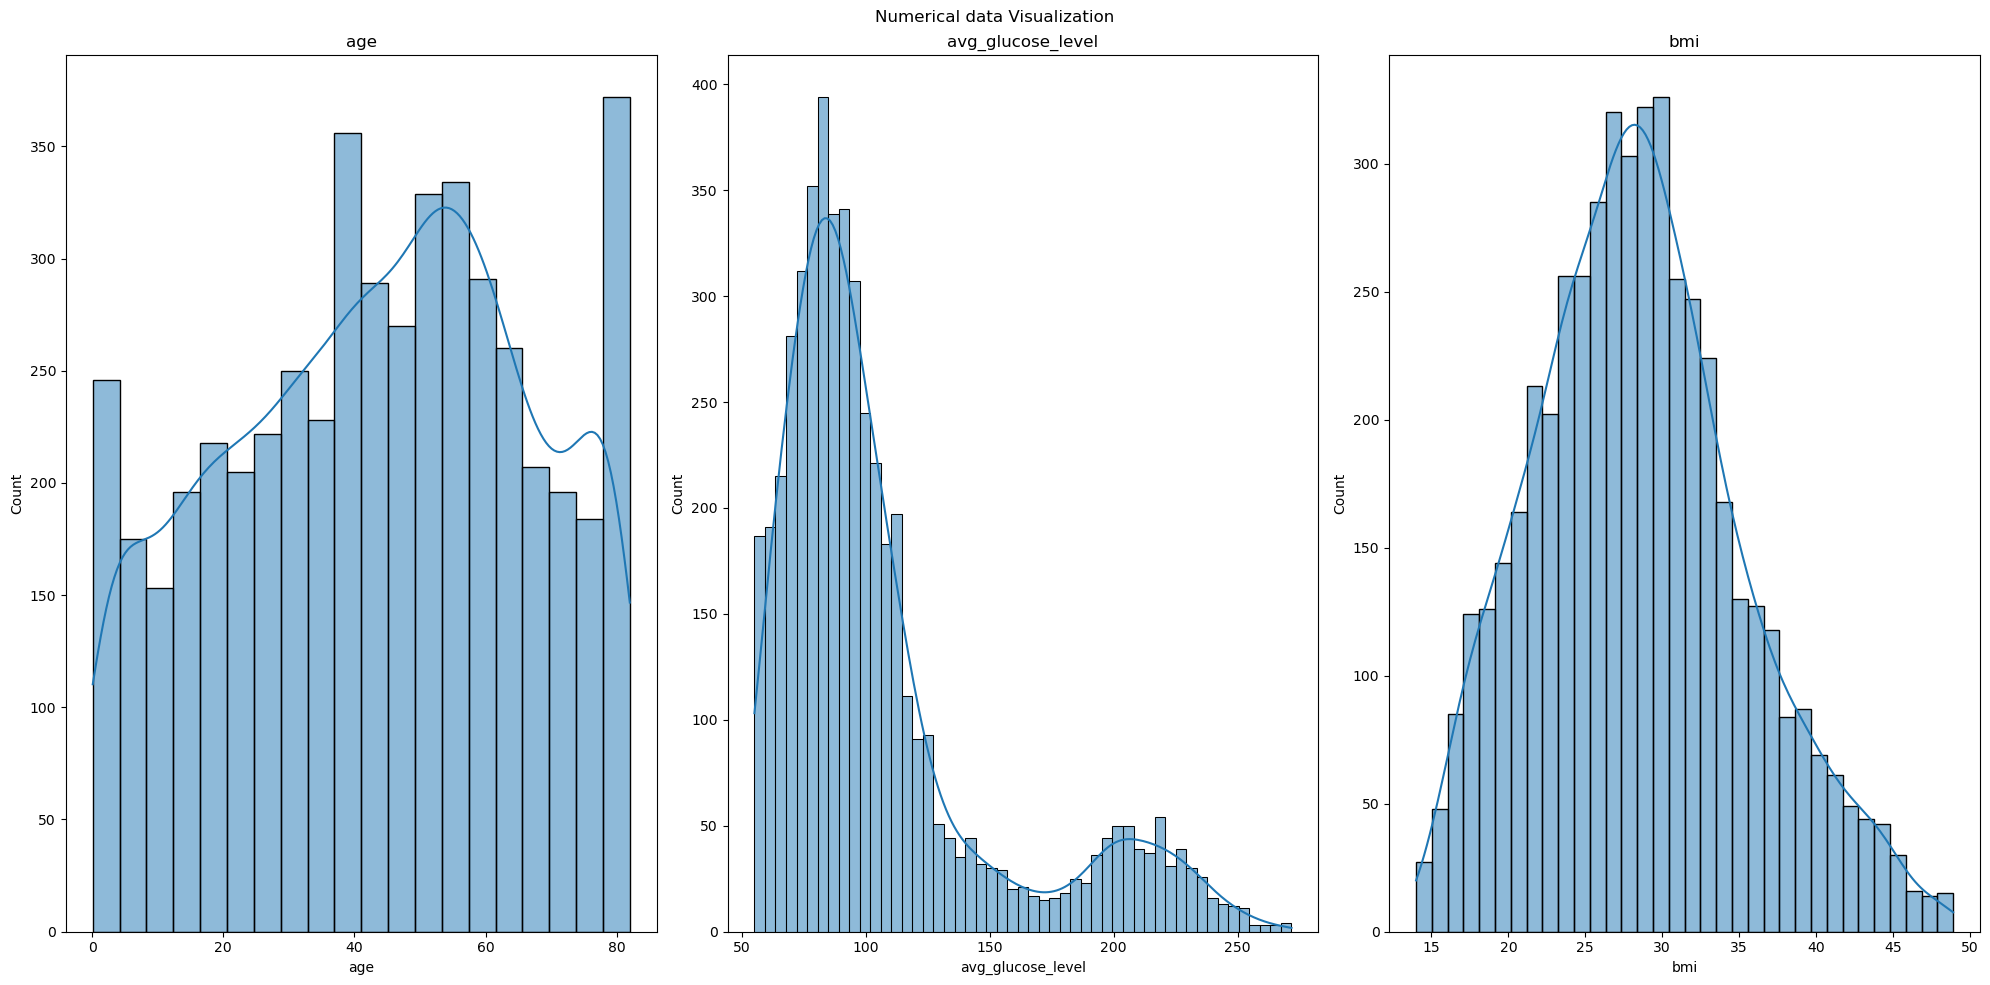

In [40]:
fig,ax=plt.subplots(1,3,figsize=(20,10))
fig.suptitle('Numerical data Visualization')
for i,col in enumerate(numerical_data.columns):
    axs=ax[i%3]
    sns.histplot(x=df[col],ax=axs,kde=True)
    axs.set_title(col)
    plt.tight_layout()
plt.show()

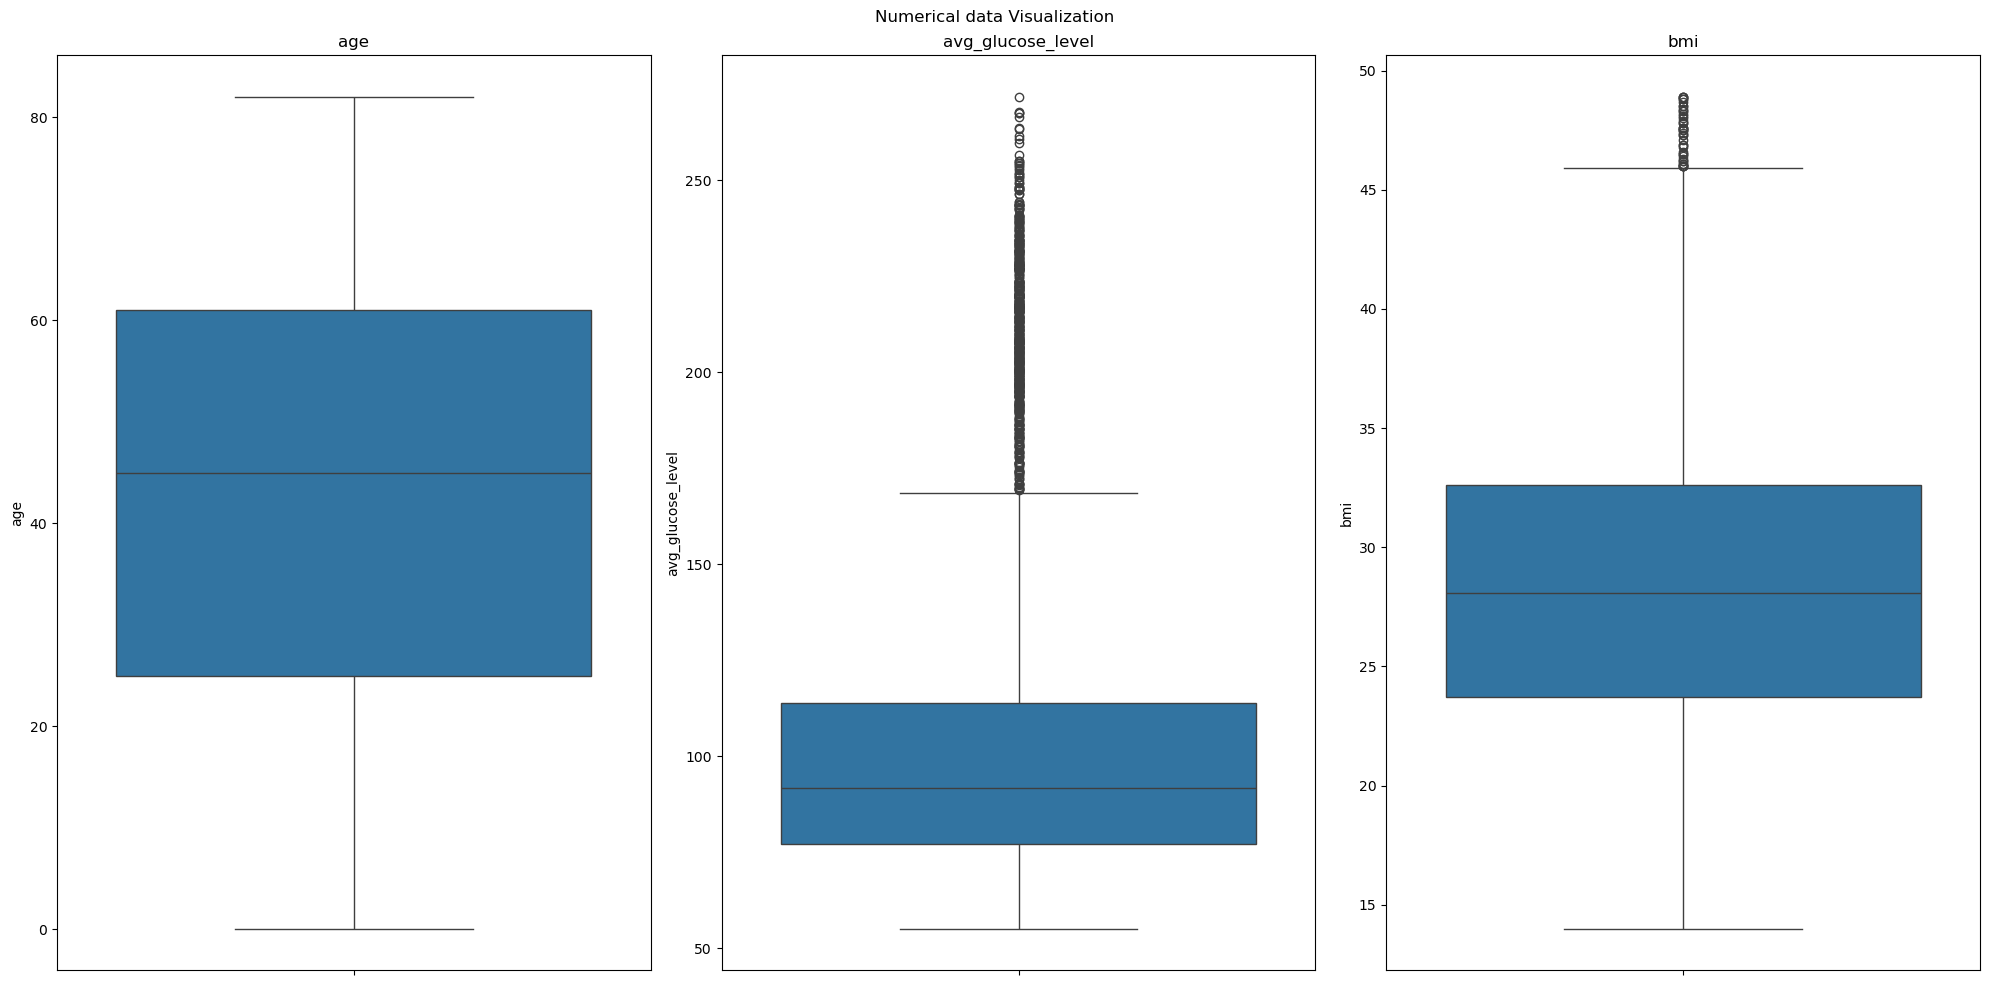

In [41]:
fig,ax=plt.subplots(1,3,figsize=(20,10))
fig.suptitle('Numerical data Visualization')
for i,col in enumerate(numerical_data.columns):
    axs=ax[i%3]
    sns.boxplot(df[col],ax=axs)
    axs.set_title(col)
    plt.tight_layout()
plt.show()

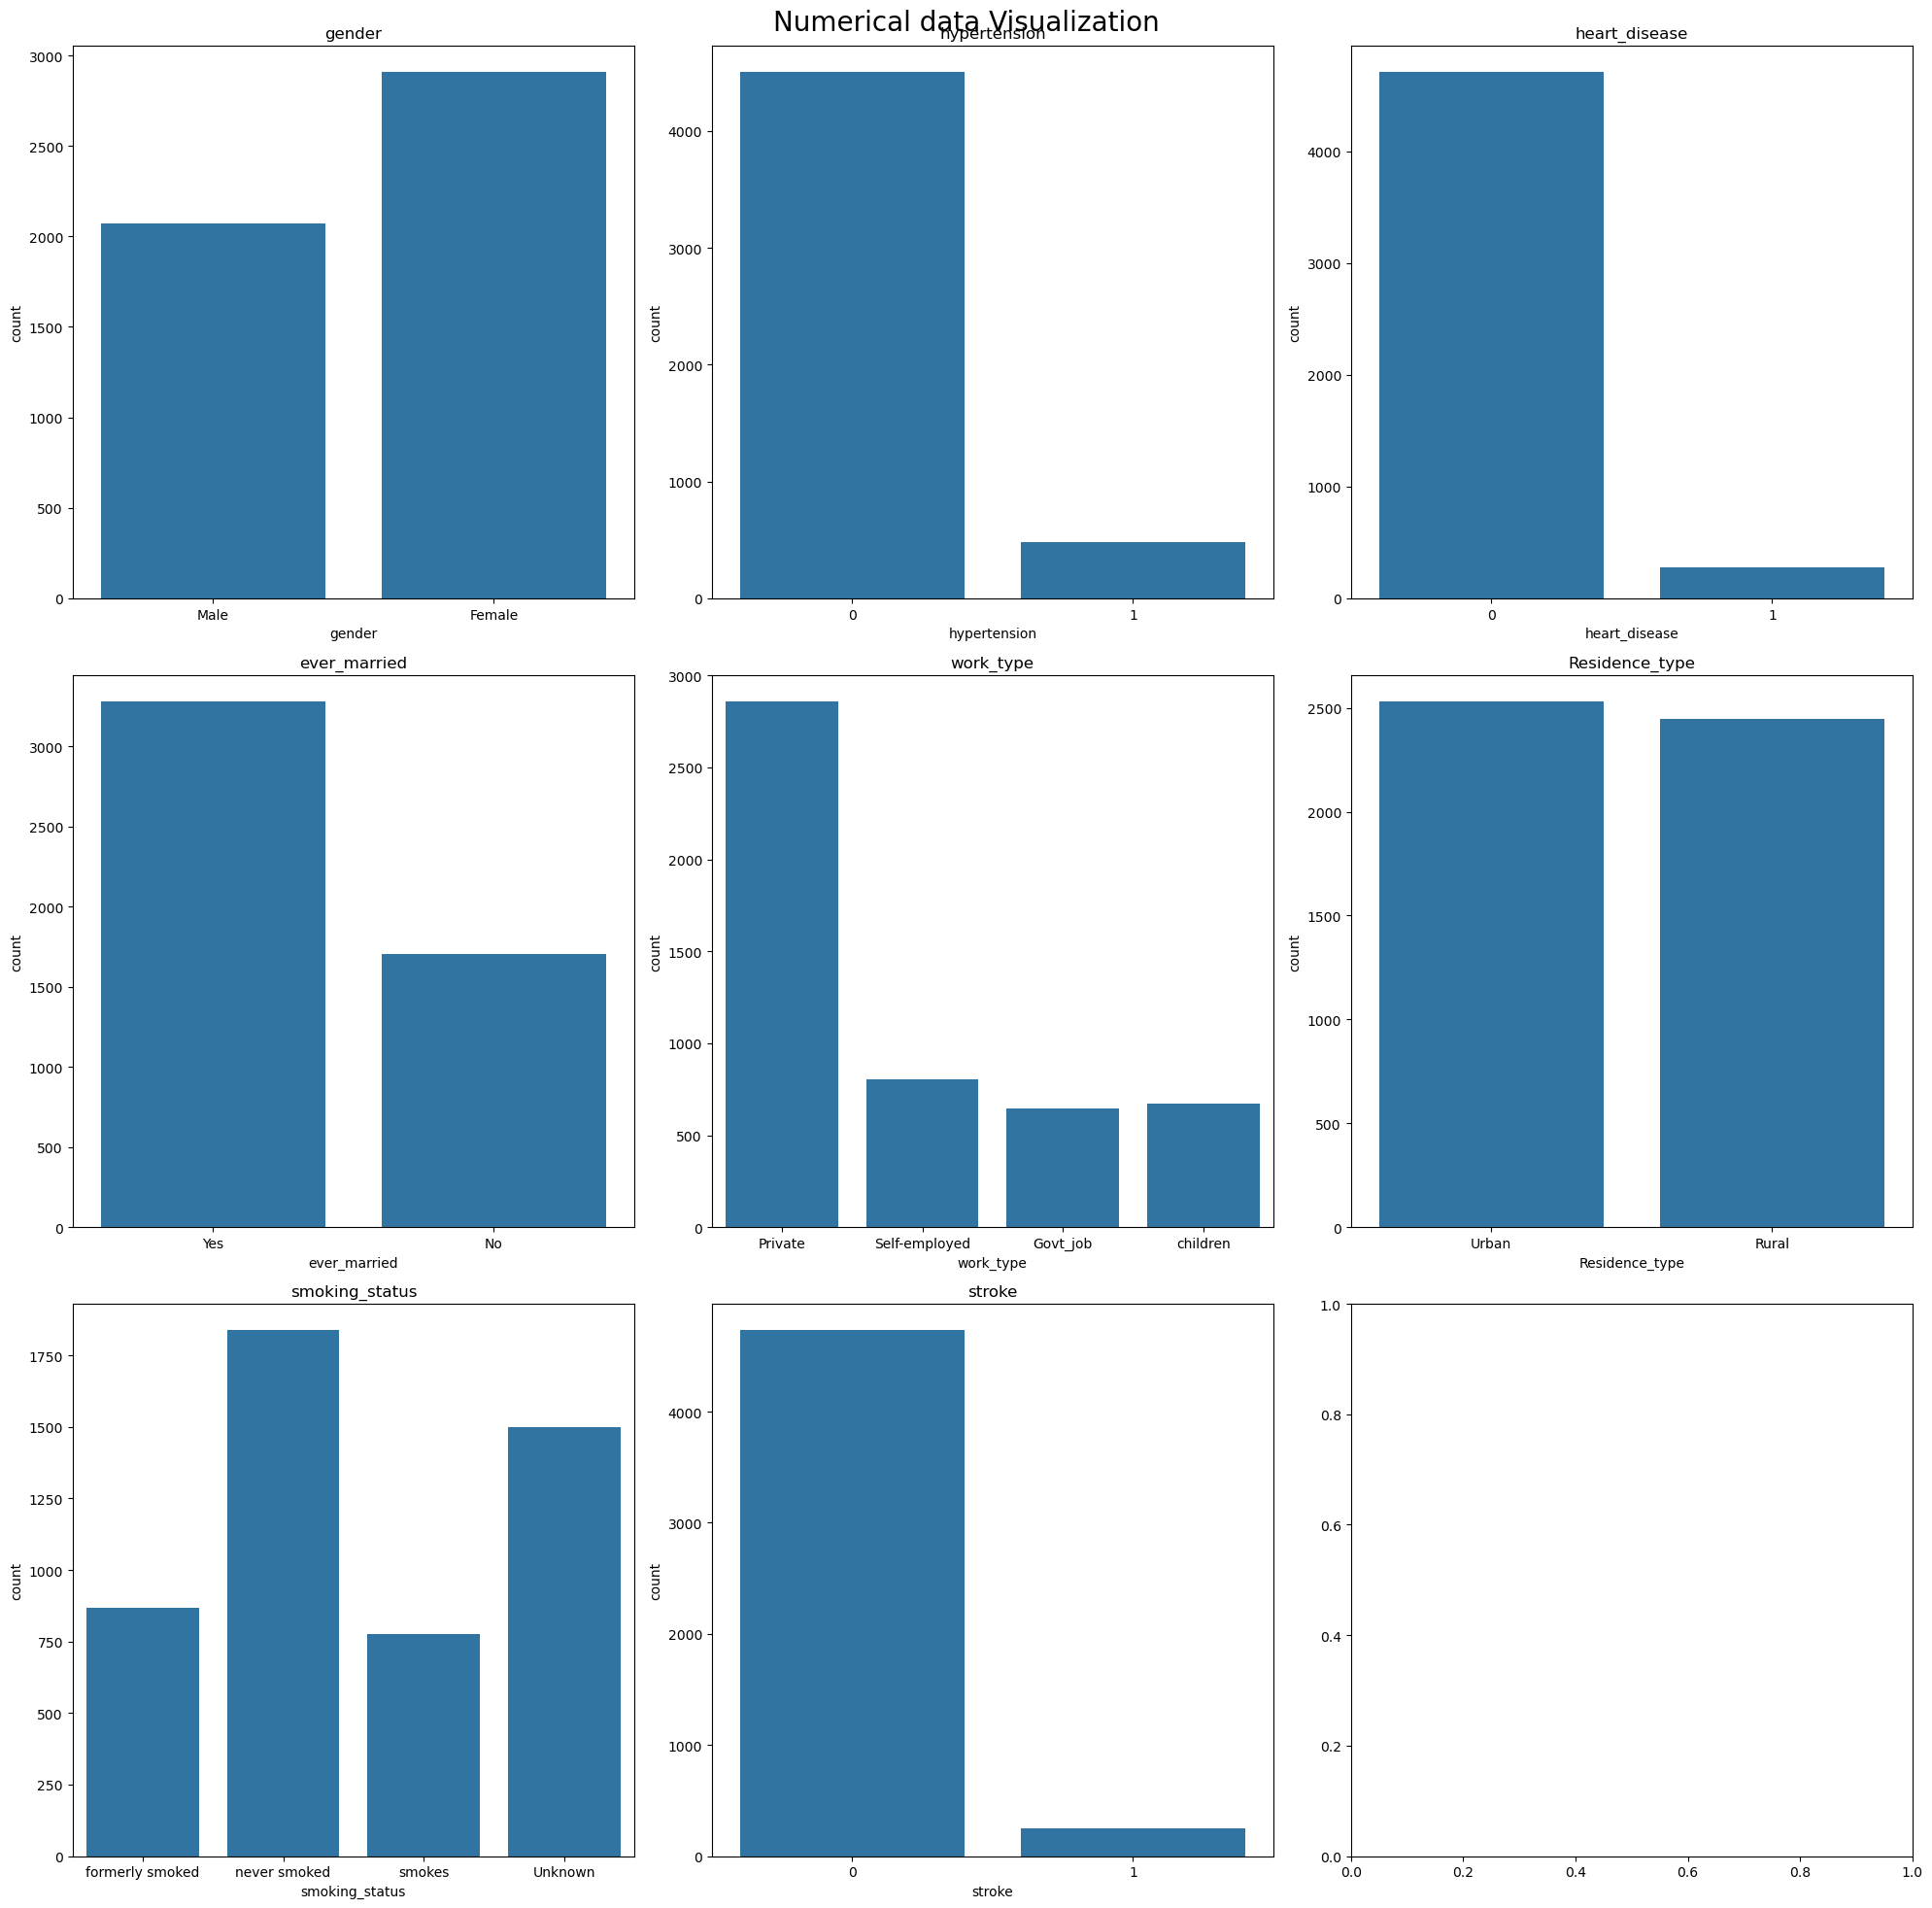

In [42]:
fig,ax=plt.subplots(3,3,figsize=(20,20))
fig.suptitle('Numerical data Visualization',fontsize=20)
for i,col in enumerate(categorical_data.columns):
    axs=ax[i//3,i%3]
    sns.countplot(x=df[col],ax=axs)
    axs.set_title(col)
    plt.tight_layout()
plt.show()

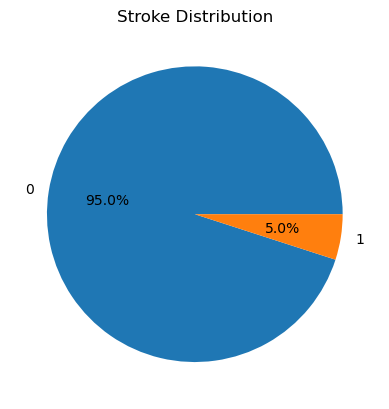

In [43]:
value_counts = df['stroke'].value_counts()

plt.pie(value_counts, autopct='%1.1f%%', labels=value_counts.index)
plt.title('Stroke Distribution')
plt.ylabel('')
plt.show()

## **Data Preprocessing** 

In [44]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
4976,Male,41.0,0,0,No,Private,Rural,70.15,29.8,formerly smoked,0
4977,Male,40.0,0,0,Yes,Private,Urban,191.15,31.1,smokes,0
4978,Female,45.0,1,0,Yes,Govt_job,Rural,95.02,31.8,smokes,0
4979,Male,40.0,0,0,Yes,Private,Rural,83.94,30.0,smokes,0


In [45]:
category_data=['gender','ever_married','work_type','Residence_type','smoking_status']

encoder=OneHotEncoder(drop='first')
encoding_data=encoder.fit_transform(df[category_data])
encoded_data_dense = encoding_data.toarray()
encoded_data_int = encoded_data_dense.astype(int)

encod_df=pd.DataFrame(data=encoded_data_int,columns=encoder.get_feature_names_out(category_data))
new_df=pd.concat([df.drop(category_data,axis=1),encod_df],axis=1)

In [46]:
new_df

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,1,1,1,0,0,1,1,0,0
1,80.0,0,1,105.92,32.5,1,1,1,1,0,0,0,0,1,0
2,49.0,0,0,171.23,34.4,1,0,1,1,0,0,1,0,0,1
3,79.0,1,0,174.12,24.0,1,0,1,0,1,0,0,0,1,0
4,81.0,0,0,186.21,29.0,1,1,1,1,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4976,41.0,0,0,70.15,29.8,0,1,0,1,0,0,0,1,0,0
4977,40.0,0,0,191.15,31.1,0,1,1,1,0,0,1,0,0,1
4978,45.0,1,0,95.02,31.8,0,0,1,0,0,0,0,0,0,1
4979,40.0,0,0,83.94,30.0,0,1,1,1,0,0,0,0,0,1


In [47]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             4981 non-null   float64
 1   hypertension                    4981 non-null   int64  
 2   heart_disease                   4981 non-null   int64  
 3   avg_glucose_level               4981 non-null   float64
 4   bmi                             4981 non-null   float64
 5   stroke                          4981 non-null   int64  
 6   gender_Male                     4981 non-null   int64  
 7   ever_married_Yes                4981 non-null   int64  
 8   work_type_Private               4981 non-null   int64  
 9   work_type_Self-employed         4981 non-null   int64  
 10  work_type_children              4981 non-null   int64  
 11  Residence_type_Urban            4981 non-null   int64  
 12  smoking_status_formerly smoked  49

In [48]:
new_df.corr()['stroke'].sort_values()

work_type_children               -0.085075
smoking_status_never smoked      -0.004806
smoking_status_smokes             0.008561
gender_Male                       0.008870
work_type_Private                 0.010459
Residence_type_Urban              0.016494
bmi                               0.056926
work_type_Self-employed           0.062643
smoking_status_formerly smoked    0.065320
ever_married_Yes                  0.108398
hypertension                      0.131965
avg_glucose_level                 0.133227
heart_disease                     0.134610
age                               0.246478
stroke                            1.000000
Name: stroke, dtype: float64

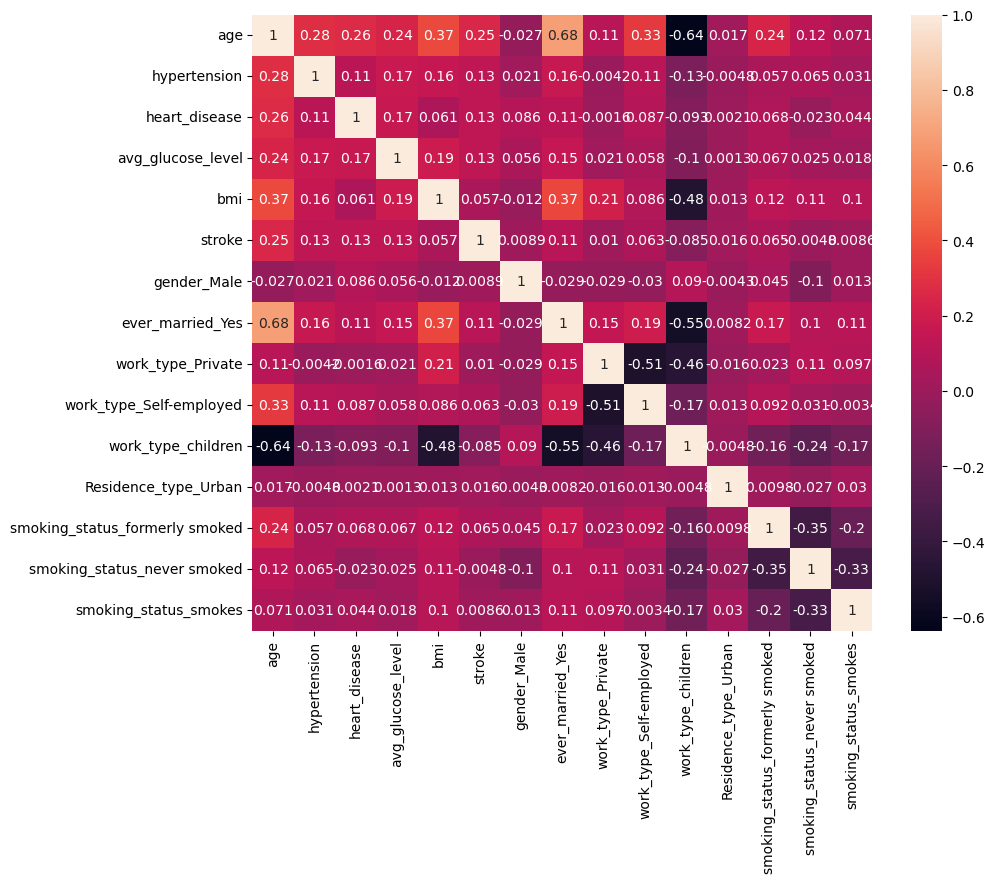

In [49]:
plt.figure(figsize=(10,8))
sns.heatmap(new_df.corr(),annot=True)
plt.show()

In [50]:
x=new_df.drop('stroke',axis=1)
y=new_df['stroke']

In [51]:
sampler=SMOTE(random_state=42)
x_sample,y_sample=sampler.fit_resample(x,y)

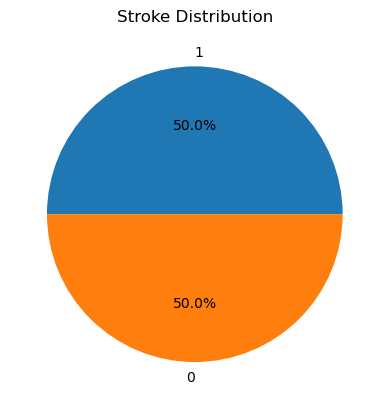

In [52]:
value_counts = y_sample.value_counts()

plt.pie(value_counts, autopct='%1.1f%%', labels=value_counts.index)
plt.title('Stroke Distribution')
plt.ylabel('')
plt.show()

In [53]:
x_train,x_test,y_train,y_test=train_test_split(x_sample,y_sample,random_state=42,test_size=0.20)

In [54]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((7572, 14), (1894, 14), (7572,), (1894,))

In [55]:
models={
    'LogisticRegression':LogisticRegression(),
    'DecisionTree':DecisionTreeClassifier(),
    'RandomForest':RandomForestClassifier(),
    'AdaBoost':AdaBoostClassifier(),
    'xgb':XGBClassifier(),
    'knn':KNeighborsClassifier(),
    'GradientBoost':GradientBoostingClassifier()
}

param_grid={
    'LogisticRegression':{
        'C': [0.1, 1, 10],
        'penalty':['l1', 'l2', 'elasticnet']
    },
    'DecisionTree':{
        'max_depth':[5,10,15],
        'min_samples_split':[2,5,10],
        'min_samples_leaf':[1,2,5]
    },
    'RandomForest':{
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10]
    },
    'AdaBoost':{
        'n_estimators': [50,100,150],
        'learning_rate':[0.1,0.5,1,2]
    },
    'xgb':{
        'n_estimators': [50,100,150],
        'max_depth': [3, 5, 7],
        'learning_rate':[0.1,0.5,1,2],
        'gamma':[0.01,0.5,1,2],
    },
    'knn':{
        'n_neighbors': [ 11,13,15,17,19],
        'weights': ['uniform', 'distance'],
        'p':[3,4,5]
    },
    'GradientBoost':{
        'n_estimators': [50,100,150],
        'max_depth': [3, 5, 7],
        'learning_rate':[0.1,0.5,1,2],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 5]
    }
        
}

def train_model_Evaluate(models,param_grid,x_train,x_test,y_train,y_test):
    grid=GridSearchCV(models,param_grid,cv=5,n_jobs=-1,verbose=2)
    grid.fit(x_train,y_train)
    best_model=grid.best_estimator_
    
    ypred=best_model.predict(x_test)
    
    accuracy=accuracy_score(y_test,ypred)
    precision=precision_score(y_test,ypred)
    recall=recall_score(y_test,ypred)
    roc_auc=roc_auc_score(y_test,ypred)
    f1score=f1_score(y_test,ypred)
    
    return {
        'accuracy':accuracy,
        'precision':precision,
        'recall':recall,
        'roc_auc':roc_auc,
        'f1score':f1score,
        'best param':grid.best_params_
    }

In [56]:
result={}

for model_name,model in models.items():
    result[model_name]=train_model_Evaluate(model,param_grid[model_name],x_train,x_test,y_train,y_test)
print(result)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ..................................C=0.1, penalty=l1; total time=   0.0s
[CV] END ..................................C=0.1, penalty=l1; total time=   0.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

[CV] END ..................................C=0.1, penalty=l2; total time=   0.1s
[CV] END ..................................C=0.1, penalty=l2; total time=   0.1s
[CV] END ..........................C=0.1, penalty=elasticnet; total time=   0.0s
[CV] END ..........................C=0.1, penalty=elasticnet; total time=   0.0s
[CV] END ..........................C=0.1, penalty=elasticnet; total time=   0.0s
[CV] END ..........................C=0.1, penalty=elasticnet; total time=   0.0s
[CV] END ..........................C=0.1, penalty=elasticnet; total time=   0.0s
[CV] END ....................................C=1, penalty=l1; total time=   0.0s
[CV] END ....................................C=1, penalty=l1; total time=   0.0s
[CV] END ....................................C=1, penalty=l1; total time=   0.0s
[CV] END ....................................C=1, penalty=l1; total time=   0.0s
[CV] END ....................................C=1, penalty=l1; total time=   0.0s
[CV] END ...................

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

[CV] END ....................................C=1, penalty=l2; total time=   0.1s
[CV] END ..................................C=0.1, penalty=l1; total time=   0.0s
[CV] END ....................................C=1, penalty=l2; total time=   0.1s


...

[CV] END ..................learning_rate=2, n_estimators=100; total time=   1.3s
[CV] END ..................learning_rate=2, n_estimators=100; total time=   1.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


[CV] END ..................learning_rate=2, n_estimators=100; total time=   1.6s
[CV] END ..................learning_rate=2, n_estimators=100; total time=   1.6s
[CV] END ..................learning_rate=2, n_estimators=100; total time=   1.9s
[CV] END ..................learning_rate=2, n_estimators=100; total time=   1.9s
[CV] END ..................learning_rate=2, n_estimators=150; total time=   2.4s
[CV] END ..................learning_rate=2, n_estimators=150; total time=   2.5s
[CV] END ..................learning_rate=2, n_estimators=150; total time=   2.4s
[CV] END ..................learning_rate=2, n_estimators=150; total time=   2.5s
[CV] END ..................learning_rate=2, n_estimators=150; total time=   2.3s
[CV] END ..................learning_rate=2, n_estimators=150; total time=   2.1s
[CV] END ..................learning_rate=2, n_estimators=150; total time=   2.3s
[CV] END ..................learning_rate=2, n_estimators=150; total time=   2.1s
[CV] END ..................l

/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV] END gamma=0.01, learning_rate=0.1, max_depth=3, n_estimators=50; total time=   0.1s
[CV] END gamma=0.01, learning_rate=0.1, max_depth=3, n_estimators=50; total time=   0.1s
[CV] END gamma=0.01, learning_rate=0.1, max_depth=3, n_estimators=50; total time=   0.1s
[CV] END gamma=0.01, learning_rate=0.1, max_depth=3, n_estimators=50; total time=   0.1s
[CV] END gamma=0.01, learning_rate=0.1, max_depth=3, n_estimators=50; total time=   0.1s
[CV] END gamma=0.01, learning_rate=0.1, max_depth=3, n_estimators=100; total time=   0.1s
[CV] END gamma=0.01, learning_rate=0.1, max_depth=3, n_estimators=100; total time=   0.1s
[CV] END gamma=0.01, learning_rate=0.1, max_depth=3, n_estimators=100; total time=   0.1s
[CV] END gamma=0.01, learning_rate=0.1, max_depth=3, n_estimators=100; total time=   0.1s
[CV] END gamma=0.01, learning_rate=0.1, max_depth=3, n_estimators=100; total time=   0.1s
[CV] END gamma=0.01, learning_rate=0.1, ma

In [57]:
result['LogisticRegression']

{'accuracy': 0.8637803590285111,
 'precision': 0.8631578947368421,
 'recall': 0.8649789029535865,
 'roc_auc': 0.8637790920687594,
 'f1score': 0.8640674394099052,
 'best param': {'C': 10, 'penalty': 'l2'}}

In [58]:
result['RandomForest']

{'accuracy': 0.9498416050686378,
 'precision': 0.9475341028331584,
 'recall': 0.9525316455696202,
 'roc_auc': 0.9498387614740278,
 'f1score': 0.9500263019463441,
 'best param': {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}}

In [59]:
result['AdaBoost']

{'accuracy': 0.8833157338965153,
 'precision': 0.8862911795961743,
 'recall': 0.879746835443038,
 'roc_auc': 0.883319506516445,
 'f1score': 0.8830068819481207,
 'best param': {'learning_rate': 1, 'n_estimators': 150}}

In [60]:
result['xgb']

{'accuracy': 0.9503695881731784,
 'precision': 0.9438669438669439,
 'recall': 0.9578059071729957,
 'roc_auc': 0.9503617273708531,
 'f1score': 0.9507853403141361,
 'best param': {'gamma': 0.01,
  'learning_rate': 0.5,
  'max_depth': 7,
  'n_estimators': 150}}

In [61]:
result['knn']


{'accuracy': 0.8870116156282999,
 'precision': 0.8259325044404974,
 'recall': 0.9810126582278481,
 'roc_auc': 0.8869122487756577,
 'f1score': 0.896817743490839,
 'best param': {'n_neighbors': 11, 'p': 3, 'weights': 'distance'}}

In [62]:
result['DecisionTree']

{'accuracy': 0.9202745512143612,
 'precision': 0.9070480081716037,
 'recall': 0.9367088607594937,
 'roc_auc': 0.9202571787941233,
 'f1score': 0.9216398546964193,
 'best param': {'max_depth': 15,
  'min_samples_leaf': 1,
  'min_samples_split': 2}}

In [63]:
result['GradientBoost']


{'accuracy': 0.9593453009503696,
 'precision': 0.9637912673056444,
 'recall': 0.9546413502109705,
 'roc_auc': 0.9593502734141534,
 'f1score': 0.9591944886062533,
 'best param': {'learning_rate': 0.5,
  'max_depth': 7,
  'min_samples_leaf': 5,
  'min_samples_split': 2,
  'n_estimators': 150}}

In [64]:
def evaluate_model(x_train,x_test,y_train,y_test,ypred,model):
    print(f'Accuracy of train = {model.score(x_train,y_train)}')
    print(f'Accuracy of test = {model.score(x_test,y_test)}') 
    print()
    
    print(classification_report(y_test,ypred))
    print()
    
    cm=confusion_matrix(y_test,ypred)
    sns.heatmap(cm,annot=True,cmap='Blues',fmt='d')
    plt.title('confusion matrix of GradientBoosting')
    plt.xlabel('Predicated')
    plt.ylabel('True values')
    plt.show()
    

Accuracy of train = 1.0
Accuracy of test = 0.9609292502639916

              precision    recall  f1-score   support

           0       0.96      0.97      0.96       946
           1       0.97      0.95      0.96       948

    accuracy                           0.96      1894
   macro avg       0.96      0.96      0.96      1894
weighted avg       0.96      0.96      0.96      1894




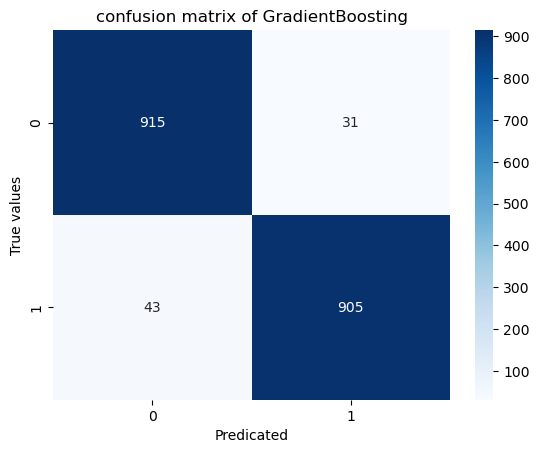

In [65]:
model=GradientBoostingClassifier(learning_rate=0.5,
                                    max_depth=7,
                                    min_samples_leaf=5,
                                    min_samples_split=2,n_estimators=150)
    
model.fit(x_train,y_train)
    
y_pred=model.predict(x_test)
    
evaluate_model(x_train,x_test,y_train,y_test,y_pred,model)

In [66]:
with open('stroke_QA.pkl', 'wb') as file:
    pickle.dump(model, file)